# Solution of NX-465 Mini-project MP2
## Spatial Navigation using Grid Cells: Path Integration in 2D Space
**Spring semester 2026**

*Team members: Kamegne Yann Eddy Sipofo & Arthur Stefano Moscheni*


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d, convolve
from tqdm.auto import tqdm

# Global simulation parameters
tau = 10.0   # membrane time constant (ms)
dt= 1.0    # integration time step (ms)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

c:\Users\mosch\OneDrive - epfl.ch\Epfl\NX465-Neuronal-Dynamics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Exercise 0 — Getting Started: Ring Attractors in 1D

We simulate a field model for a 1D ring of neurons. The potential $s(x,t)$ evolves as:

$$\tau \frac{ds(x,t)}{dt} = -s(x,t) + I^{rec}(x,t) + B(x,t)$$

with recurrent input (convolution of firing rate with a Mexican-hat kernel):

$$I^{rec}(x,t) = \int W(x-x')\,r(x',t)\,dx', \qquad r(x,t)=\max(0,\,s(x,t))$$

$$W(x) = A_{exc}\,e^{-x^2/\sigma_{exc}^2} - A_{inh}\,e^{-x^2/\sigma_{inh}^2}$$

**0.1.** Write a Python function `mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)` that computes
the 1D interaction weight at distance $x$.

**0.2.** Plot the weight kernel for an array of $M = 100$ neurons centered around 0
($x \in [-M/2,\,M/2)$, equally spaced), using parameters:
$A_{exc}=0.3$, $\sigma_{exc}=5.0$, $A_{inh}=0.2$, $\sigma_{inh}=10.0$.


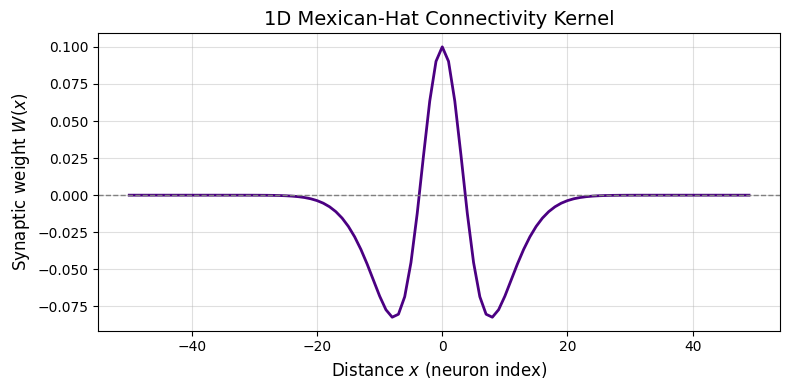

In [3]:
# Exercise 0.1 & 0.2

def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    """W(x) = A_exc * exp(-x²/σ_exc²) - A_inh * exp(-x²/σ_inh²)"""
    return (  A_exc * np.exp(-(x**2) / sigma_exc**2)
            - A_inh * np.exp(-(x**2) / sigma_inh**2))

M = 100
A_exc = 0.3;  sigma_exc = 5.0
A_inh = 0.2;  sigma_inh = 10.0

x_vals = np.arange(-M /2, M / 2)
W_1d = mexican_hat_1d(x_vals, A_exc, sigma_exc, A_inh, sigma_inh)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, W_1d, color='indigo', lw=2)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Distance $x$ (neuron index)')
ax.set_ylabel('Synaptic weight $W(x)$')
ax.set_title('1D Mexican-Hat Connectivity Kernel')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**0.3. Biological interpretation of the Mexican-hat kernel**

The Mexican-hat profile represents an *effective* anatomical coupling within the cortical sheet. The short-range positive lobe reflects local recurrent excitation between nearby pyramidal cells. The broader negative surround accounts for the effective long-range lateral inhibition mediated by local interneurons, which receive local excitatory input but project inhibitory synapses over significantly greater distances than the excitatory cells.


**0.4.** Use the Forward Euler method with $\Delta t = 1$ ms to integrate the dynamics of this
1D network over 500 ms. Plot the evolution of the firing rate $r(x,t)$.

Parameters: $\tau=10$ ms, $B(x,t)=1.0$. Randomly initialise $s(x,0)\sim\text{Uniform}(0,0.1)$.

*Hint:* implement the convolution $\int W(x-x')r(x')\,dx'$ with `scipy.ndimage.convolve1d`
using `mode='wrap'` for periodic boundaries.


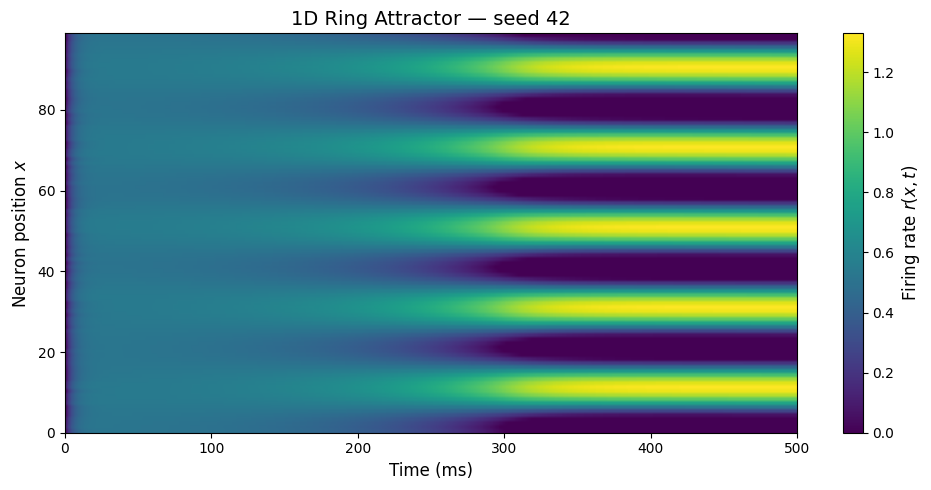

In [4]:
# Exercise 0.4

def simulate_1d_ring(seed, T=500.0, B=1.0):
    """1D ring attractor. Returns rate history (n_steps, M)."""
    np.random.seed(seed)
    n_steps= int(T / dt)
    s = np.random.uniform(0.0, 0.1, M)
    rates_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        r = np.maximum(0.0, s)
        rates_hist[t] = r
        I_rec = convolve1d(r, W_1d, mode='wrap')
        s = s+ dt * (-s + I_rec + B) / tau

    return rates_hist

seed_demo = 42
rates_demo = simulate_1d_ring(seed=seed_demo)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(rates_demo.T, aspect='auto', origin='lower',
               extent=[0, 500, 0, M - 1], cmap='viridis')
plt.colorbar(im, ax=ax, label='Firing rate $r(x,t)$')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron position $x$')
ax.set_title(f'1D Ring Attractor — seed {seed_demo}')
plt.tight_layout()
plt.show()

**0.5.** Describe the behaviour of the network using 3 different random seeds.
Does the behaviour depend on the initialisation of $s(x,0)$?


C:\Users\mosch\AppData\Local\Temp\ipykernel_10996\3188395737.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


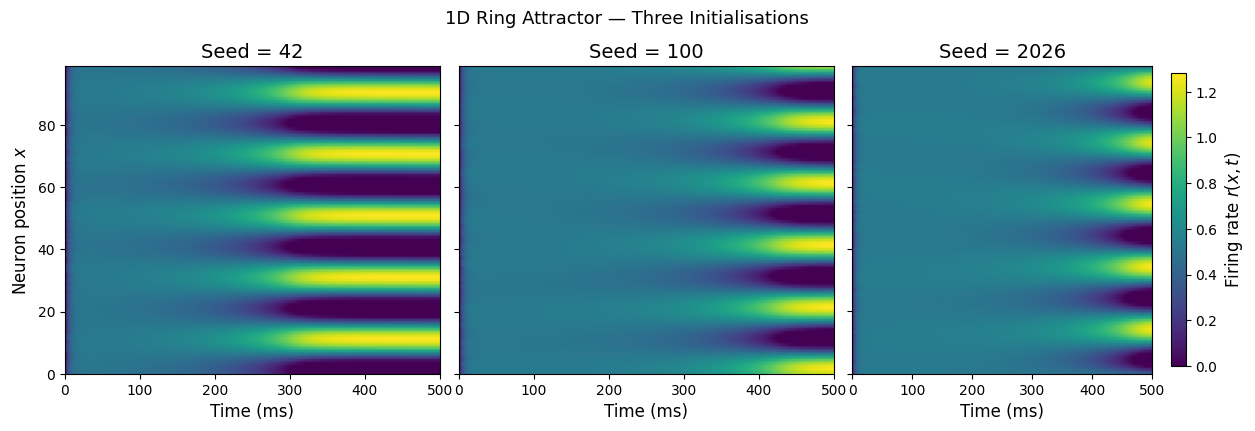

In [5]:
# Exercise 0.5

seeds = [42, 100, 2026]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True,
                         gridspec_kw={'wspace': 0.05})
for ax, seed in zip(axes, seeds):
    rates = simulate_1d_ring(seed=seed)
    im = ax.imshow(rates.T, aspect='auto', origin='lower',
                      extent=[0, 500, 0, M - 1], cmap='viridis')
    ax.set_title(f'Seed = {seed}')
    ax.set_xlabel('Time (ms)')

axes[0].set_ylabel('Neuron position $x$')
fig.colorbar(im, ax=axes[2], label='Firing rate $r(x,t)$', shrink=0.95)
plt.suptitle('1D Ring Attractor — Three Initialisations', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('images2/fig_0_5_seeds.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Ex 0.5):**

The network's macroscopic equilibrium state — a localized activity bump — is robust and *independent* of the initial noise. However, its exact spatial phase (location) is entirely determined by the initial conditions via spontaneous symmetry breaking. This defines a **continuous attractor**: the network possesses a continuous manifold of marginally stable fixed points that are translationally equivalent, enabling it to maintain a persistent spatial memory devoid of predefined boundaries.


---
## Exercise 1 — 1D Velocity Integration

To track velocity we split the population into two sub-populations:
a **right-shifting** (R) and a **left-shifting** (L) population, each of $M=100$ neurons.
Their shifted kernels are:

$$W_R(x-x') = W(x-x'-l), \qquad W_L(x-x') = W(x-x'+l)$$

and the external inputs are modulated asymmetrically by velocity $v(t)$:

$$B_R = B_0(1+\alpha v(t)), \qquad B_L = B_0(1-\alpha v(t))$$

The total recurrent input to any neuron is the sum from both populations:

$$I^{rec}(x,t)=\int W_R(x-x')r_R(x',t)\,dx' + \int W_L(x-x')r_L(x',t)\,dx'$$

**1.1.** Write a simulation function for this 2-population integrator.
Parameters: $B_0=1.5$, $\alpha=0.5$, $l=1.0$.
Run for 1000 ms: $v=0$ for the first 300 ms (let bump stabilise), $v=1.0$ from 300–700 ms,
$v=0$ afterwards. Plot $r_{total}(x,t) = r_R(x,t)+r_L(x,t)$ over time.


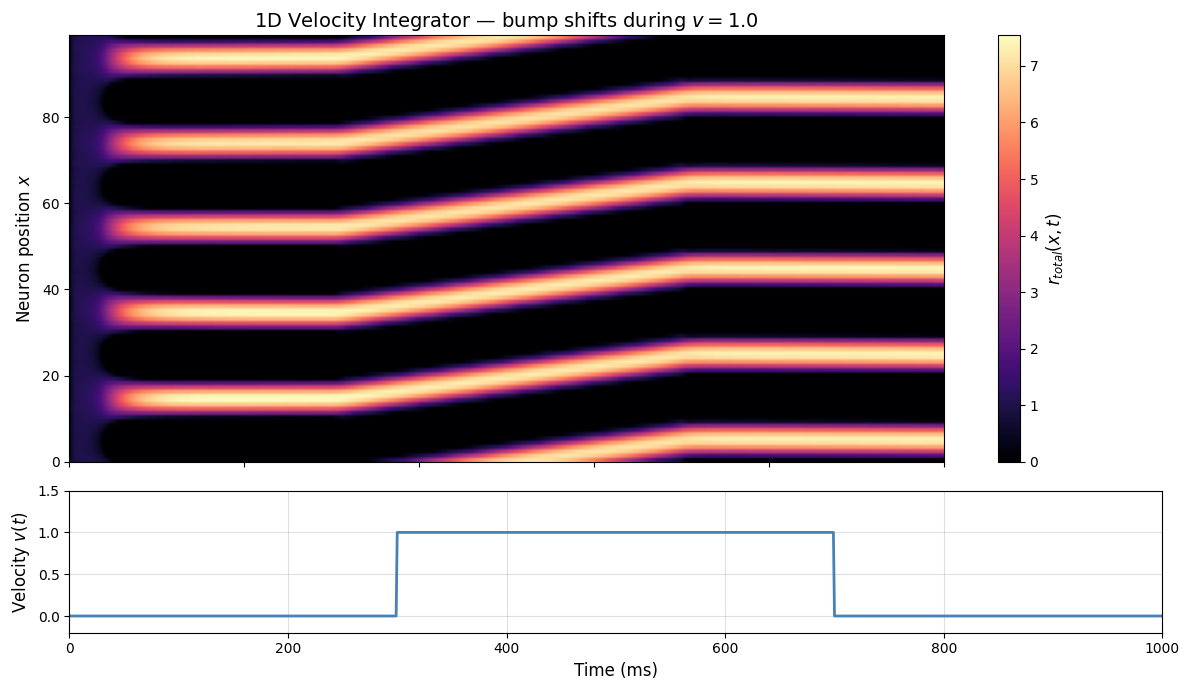

In [6]:
# Exercise 1.1

B0= 1.5
alpha = 0.5
l = 1.0   # kernel shift (neuron-index units)

WR_1d = mexican_hat_1d(x_vals - l, A_exc, sigma_exc, A_inh, sigma_inh)
WL_1d = mexican_hat_1d(x_vals + l, A_exc, sigma_exc, A_inh, sigma_inh)


def simulate_1d_integrator(v_arr, T=1000.0, seed=42):
    """1D velocity integrator (R/L populations). Returns r_total history (n_steps, M)."""
    np.random.seed(seed)
    n_steps = int(T / dt)

    s_R = np.random.uniform(0.0, 0.1, M)
    s_L = np.random.uniform(0.0, 0.1, M)
    r_total_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        v = v_arr[t]
        r_R = np.maximum(0.0, s_R)
        r_L = np.maximum(0.0, s_L)

        r_total_hist[t] = r_R + r_L

        I_rec = (convolve1d(r_R, WR_1d, mode='wrap') + convolve1d(r_L, WL_1d, mode='wrap'))

        B_R = B0 * (1 + alpha * v)
        B_L = B0 * (1 - alpha * v)

        s_R = s_R + dt * (-s_R + I_rec + B_R) / tau
        s_L = s_L + dt * (-s_L + I_rec + B_L) / tau

    return r_total_hist


T11= 1000.0
n11 = int(T11 / dt)
time_11 = np.arange(n11) * dt

v_11 = np.zeros(n11)
v_11[(time_11 >= 300) & (time_11 < 700)] = 1.0

r_hist_11 = simulate_1d_integrator(v_11, T=T11)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
im = axes[0].imshow(r_hist_11.T, aspect='auto', origin='lower',
                    extent=[0, T11, 0, M - 1], cmap='magma')
fig.colorbar(im, ax=axes[0], label=r'$r_{total}(x,t)$')
axes[0].set_ylabel('Neuron position $x$')
axes[0].set_title('1D Velocity Integrator — bump shifts during $v=1.0$')

axes[1].plot(time_11, v_11, color='steelblue', lw=2)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Velocity $v(t)$')
axes[1].set_ylim(-0.2, 1.5)
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**1.2. Mechanism of velocity-driven shifting**

When $v > 0$, the right-shifting population receives a stronger feedforward drive ($B_R > B_L$). Due to the anatomically shifted recurrent kernel $W_R$, the R neurons preferentially project their maximal excitation ahead of the current bump position (by a spatial offset $l$). This structural asymmetry, combined with the firing rate imbalance, systematically biases the recurrent excitatory input towards the right flank of the bump, while simultaneously inhibiting the left flank via the Mexican-hat surround. As a result, the entire activity profile translates rightward. The drift speed is dictated by the amplitude of $v$, which governs the magnitude of the feedforward imbalance $B_R - B_L = 2\alpha B_0 v$. A negative velocity ($v < 0$) symmetrically recruits the L population, driving a leftward translation.


**1.3.** To show that the bump acts as a velocity integrator, apply a velocity signal of
varying magnitudes over time. Sample 10 velocities in $[-2,-0.5]\cup[0.5,2]$, each lasting
300 timesteps. Plot the bump evolution and velocity signal side by side.


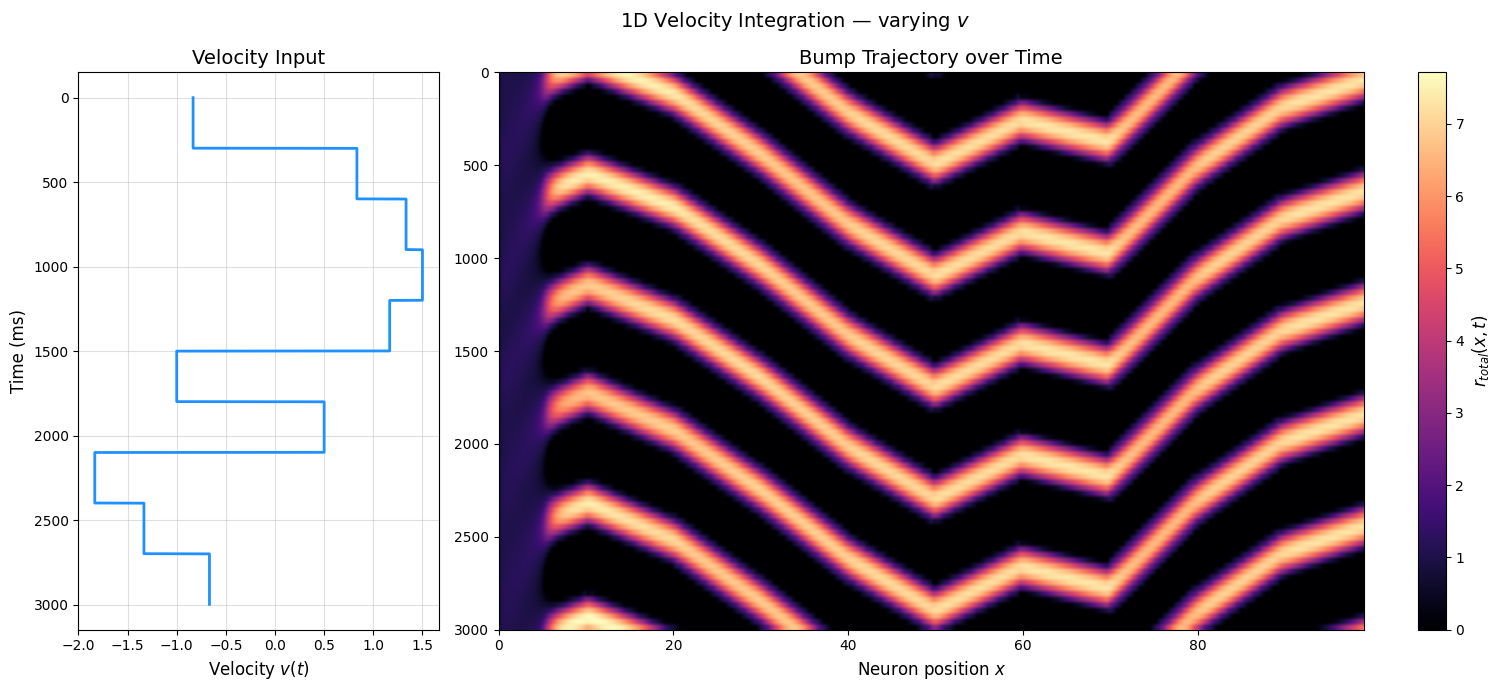

In [7]:
# Exercise 1.3

rng = np.random.default_rng(7)
pool = np.concatenate([np.linspace(-2.0, -0.5, 10),
                           np.linspace( 0.5,  2.0, 10)])
v_samples = rng.choice(pool, size=10, replace=False)

block = 300
T13 = block * 10
n13 = T13
time_13 = np.arange(n13) * dt

v_13 = np.zeros(n13)
for i, vi in enumerate(v_samples):
    v_13[i * block : (i + 1) * block] = vi

r_hist_13 = simulate_1d_integrator(v_13, T=float(T13))

fig, (ax_v, ax_r) = plt.subplots(1, 2, figsize=(16, 7),
                                  gridspec_kw={'width_ratios': [1, 3]})
ax_v.plot(v_13, time_13, color='dodgerblue', lw=2)
ax_v.set_xlabel('Velocity $v(t)$')
ax_v.set_ylabel('Time (ms)')
ax_v.set_title('Velocity Input')
ax_v.grid(True, alpha=0.4)
ax_v.invert_yaxis()

im = ax_r.imshow(r_hist_13.T, aspect='auto', origin='upper',
                 extent=[0, M - 1, T13, 0], cmap='magma')
fig.colorbar(im, ax=ax_r, label=r'$r_{total}(x,t)$')
ax_r.set_xlabel('Neuron position $x$')
ax_r.set_title('Bump Trajectory over Time')

plt.suptitle('1D Velocity Integration — varying $v$', fontsize=14)
plt.tight_layout()
plt.show()

**Observation (Ex 1.3):**

The bump moves at a speed proportional to $v(t)$, instantly reversing direction upon each velocity switch, while its shape remains stable. It wraps around the ring boundaries without disruption, confirming the periodic topology. The bump's cumulative displacement tracks the time-integral of velocity, demonstrating that the network performs path integration

**1.4.** Devise a method to compute the velocity of the moving bump. Plot measured bump velocity
vs. input velocity and check for a linear relationship.


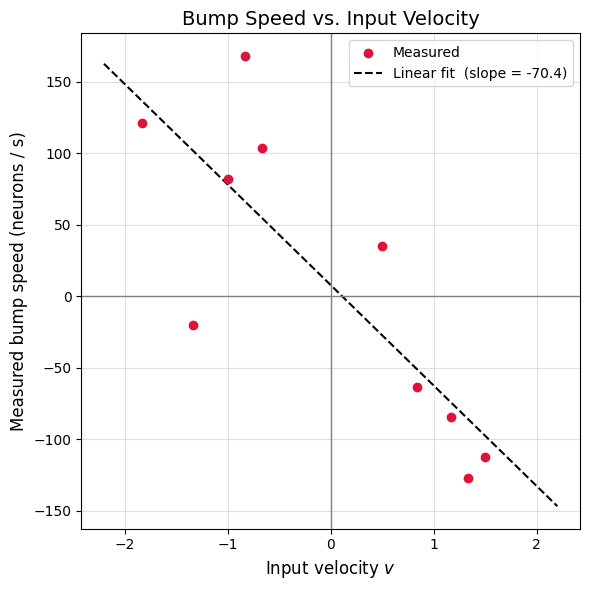

Linear fit: bump_speed ≈ -70.35 · v + 7.89


In [8]:
# Exercise 1.4

def bump_phase(r_row):
    """Angular position of the bump on the ring via first Fourier mode."""
    positions = np.arange(len(r_row))
    f_comp    = np.sum(r_row * np.exp(-1j * 2 * np.pi * positions / len(r_row)))
    return np.angle(f_comp)

phases_13 = np.array([bump_phase(r_hist_13[t]) for t in range(n13)])
phases_13_unwrapped = np.unwrap(phases_13)

phase_speed = np.diff(phases_13_unwrapped) / (2 * np.pi) * M  # neurons / ms

transient = 100
measured_v = []
input_v = []

for i in range(10):
    s_idx = i * block + transient
    e_idx = (i + 1) * block - transient
    measured_v.append(np.mean(phase_speed[s_idx:e_idx]) * 1000)
    input_v.append(v_samples[i])

measured_v = np.array(measured_v)
input_v = np.array(input_v)

coeffs= np.polyfit(input_v, measured_v, 1)
v_range = np.linspace(-2.2, 2.2, 100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(input_v, measured_v, color='crimson', zorder=5, label='Measured')
ax.plot(v_range, np.poly1d(coeffs)(v_range), 'k--',
        label=f'Linear fit  (slope = {coeffs[0]:.1f})')
ax.axhline(0, color='gray', lw=1)
ax.axvline(0, color='gray', lw=1)
ax.set_xlabel('Input velocity $v$')
ax.set_ylabel('Measured bump speed (neurons / s)')
ax.set_title('Bump Speed vs. Input Velocity')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Linear fit: bump_speed ≈ {coeffs[0]:.2f} · v + {coeffs[1]:.2f}")

**Result (Ex 1.4):**

The measured bump drift speed scales linearly with the input velocity $v$ (black dashed fit, slope ≈ −70.4 neurons/s), confirming that the network operates as a faithful velocity integrator. To measure the bump speed, we compute the angular phase of the activity pattern at each timestep using the first Fourier mode: the activity vector is projected onto a complex exponential, and the angle of the resulting complex number gives the bump's position on the ring. After phase unwrapping to remove artificial jumps when the bump crosses the ring boundary, the bump speed is obtained by finite differencing consecutive phase values. Averaging over each constant-velocity block and plotting measured speed against input velocity $v$ reveals a clear linear relationship (slope ≈ −70.4 neurons/s), confirming that the network faithfully and proportionally integrates the velocity input.


---
## Exercise 2 — Extending to 2D Grid Cells

Equations (1)–(3) extend directly to 2D with $\|\mathbf{x}\| = \sqrt{x^2+y^2}$:

$$W(\mathbf{x}) = A_{exc}\,e^{-\|\mathbf{x}\|^2/\sigma_{exc}^2}
                 - A_{inh}\,e^{-\|\mathbf{x}\|^2/\sigma_{inh}^2}$$

**2.1.** Plot the 2D mexican-hat kernel for $M=40$, $A_{exc}=A_{inh}=1.0$,
$\sigma_{exc}=4.8$, $\sigma_{inh}=5.0$.


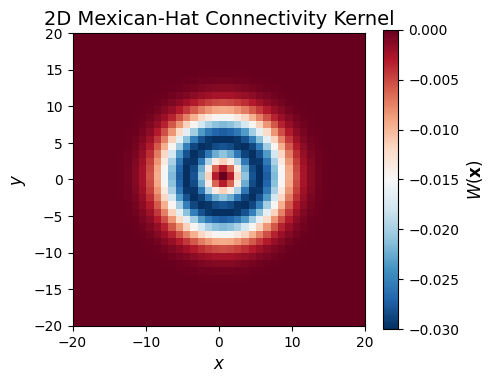

In [9]:
# Exercise 2.1

M2 = 40
A2_exc = 1.0;  sigma2_exc = 4.8
A2_inh = 1.0;  sigma2_inh = 5.0

gy, gx = np.mgrid[-M2 // 2 : M2 // 2, -M2 // 2 : M2 // 2]

def mexican_hat_2d(X, Y, A_exc, s_exc, A_inh, s_inh):
    """W(x,y) = A_exc*exp(-r²/σ_exc²) - A_inh*exp(-r²/σ_inh²), r²=X²+Y²"""
    r2 = X**2 + Y**2
    return A_exc * np.exp(-r2 / s_exc**2) - A_inh * np.exp(-r2 / s_inh**2)

W2d = mexican_hat_2d(gx, gy, A2_exc, sigma2_exc, A2_inh, sigma2_inh)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(W2d, extent=[-M2 // 2, M2 // 2, -M2 // 2, M2 // 2],
               origin='lower', cmap='RdBu_r')
plt.colorbar(im, ax=ax, label=r'$W(\mathbf{x})$')
ax.set_title('2D Mexican-Hat Connectivity Kernel')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**2.2.** Implement the 2D model with 4 velocity-shifted populations (N, S, E, W).
Use periodic (torus) boundary conditions (`mode='wrap'`).
Simulate with $\mathbf{v}=(0,0)$ for 400 ms and plot the final total firing rate.

Parameters: $\tau=10$ ms, $\Delta t=1$ ms, $l=1.0$, $\alpha=0.1$, $B_0=1.0$.


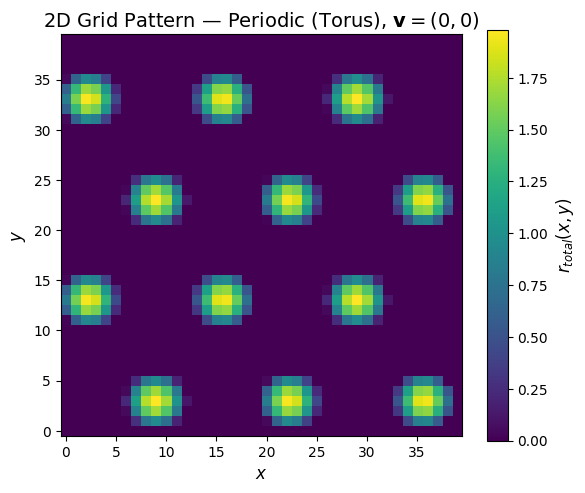

In [10]:
# Exercise 2.2

l2 = 1.0
alpha2 = 0.1
B02 = 1.0

# Four directionally shifted kernels
gy2, gx2 = np.mgrid[-M2 // 2 : M2 // 2, -M2 // 2 : M2 // 2]
W_N2 = mexican_hat_2d(gx2, gy2 - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_S2 = mexican_hat_2d(gx2, gy2 + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_E2 = mexican_hat_2d(gx2 - l2,  gy2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_W2 = mexican_hat_2d(gx2 + l2,  gy2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
KERNELS = [W_N2, W_S2, W_E2, W_W2]


def simulate_2d(vx_arr, vy_arr, T, M_val=40,
                kernels=None, mode='wrap',
                weight_mask=None, input_mask=None, seed=42):
    """2D CAN — 4 populations (N, S, E, W). Returns (r_final, snapshots)."""
    if kernels is None:
        kernels = KERNELS
    W_N, W_S, W_E, W_W = kernels

    np.random.seed(seed)
    n_steps = int(T / dt)

    s_N = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_S = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_E = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_W = np.random.uniform(0.0, 0.1, (M_val, M_val))

    snap_times = {300, 450, 600}
    snapshots = []

    for t in range(n_steps):
        vx = vx_arr[t]
        vy = vy_arr[t]

        r_N = np.maximum(0.0, s_N)
        r_S = np.maximum(0.0, s_S)
        r_E = np.maximum(0.0, s_E)
        r_W = np.maximum(0.0, s_W)

        # Weight attenuation: scale outgoing rates near boundaries
        if weight_mask is not None:
            r_N = r_N * weight_mask
            r_S = r_S * weight_mask
            r_E = r_E * weight_mask
            r_W = r_W * weight_mask

        # Recurrent input  I_rec = sum_p (W_p * r_p)
        I_rec = (convolve(r_N, W_N, mode=mode)
               + convolve(r_S, W_S, mode=mode)
               + convolve(r_E, W_E, mode=mode)
               + convolve(r_W, W_W, mode=mode))

        # Velocity-modulated feedforward drives  B_p = B_0 (1 ± alpha * v)
        B_N = B02 * (1 + alpha2 * vy)
        B_S = B02 * (1 - alpha2 * vy)
        B_E = B02 * (1 + alpha2 * vx)
        B_W = B02 * (1 - alpha2 * vx)

        # Input attenuation: scale feedforward drives near boundaries
        if input_mask is not None:
            B_N = B_N * input_mask
            B_S = B_S * input_mask
            B_E = B_E * input_mask
            B_W = B_W * input_mask

        # Forward Euler  tau * ds/dt = -s + I_rec + B
        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

        t_ms = t * dt
        if t_ms in snap_times:
            r_total = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
                     + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))
            snapshots.append((t_ms, r_total.copy()))

    r_final = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
             + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))
    return r_final, snapshots


T22 = 400.0
n22 = int(T22 / dt)
r22, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r22, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title(r'2D Grid Pattern — Periodic (Torus), $\mathbf{v}=(0,0)$')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 2.2):**

Yes, a hexagonal grid pattern is clearly visible. It emerges spontaneously via pattern formation: the 2D Mexican-hat kernel destabilizes the uniform background state and selectively amplifies a preferred spatial frequency determined by the balance of $\sigma_{exc}$ and $\sigma_{inh}$. The network then settles into a minimal-energy, translation-invariant hexagonal configuration — the hallmark of a continuous attractor network.


**2.3.** Test the 2D integrator by applying constant velocity vectors in at least 3 directions
(horizontal, vertical, diagonal). Visualise $r_{total}(x,y)$ at $t=300$, $450$, $600$ ms.


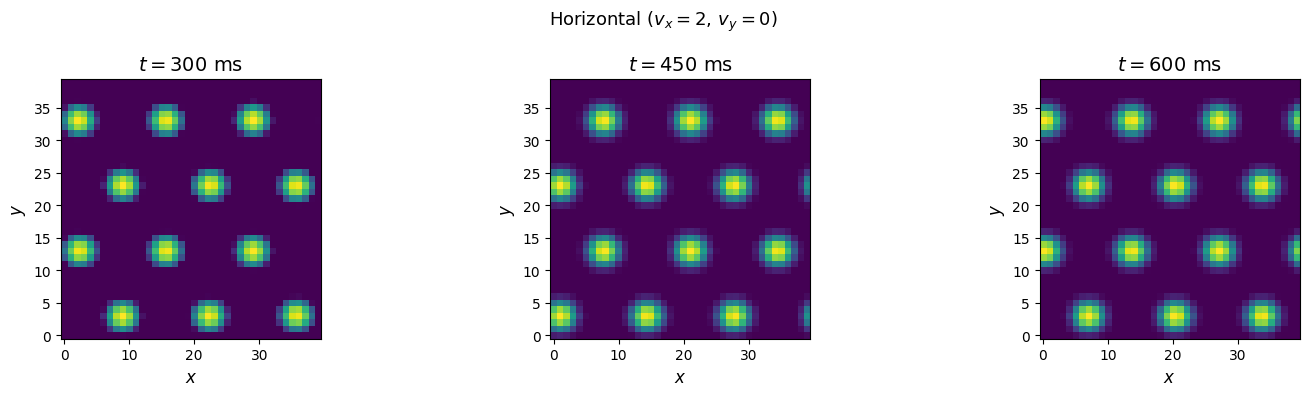

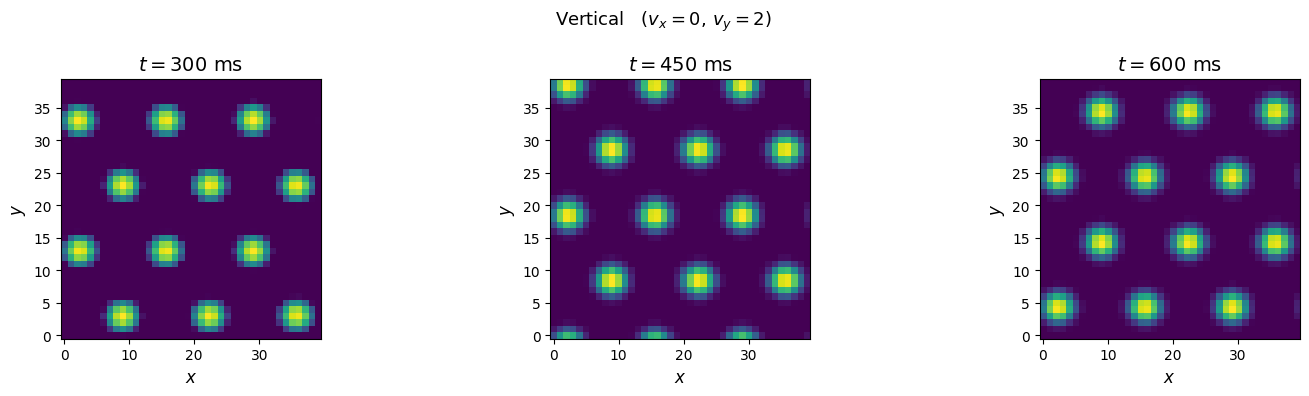

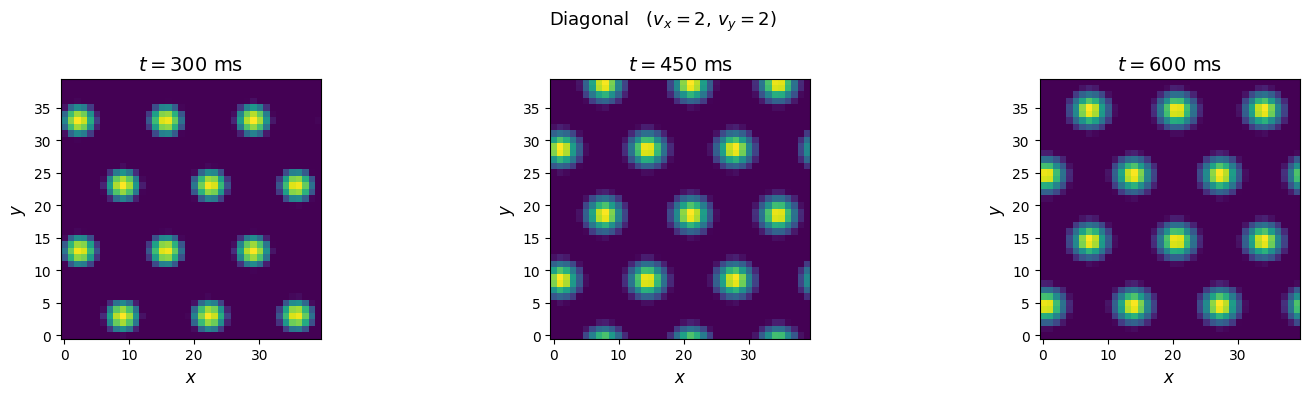

In [11]:
# Exercise 2.3

directions = {
    r'Horizontal ($v_x=2,\,v_y=0$)': (2.0, 0.0),
    r'Vertical   ($v_x=0,\,v_y=2$)': (0.0, 2.0),
    r'Diagonal   ($v_x=2,\,v_y=2$)': (2.0, 2.0),
}

T23 = 601.0
n23 = int(T23 / dt)
time_23 = np.arange(n23) * dt

for title, (vx_val, vy_val) in directions.items():
    vx_arr = np.where(time_23 >= 300, vx_val, 0.0)
    vy_arr = np.where(time_23 >= 300, vy_val, 0.0)

    _, snaps = simulate_2d(vx_arr, vy_arr, T23)
    snap_dict = {int(ts): img for ts, img in snaps}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, t_label in zip(axes, [300, 450, 600]):
        if t_label in snap_dict:
            ax.imshow(snap_dict[t_label], origin='lower', cmap='viridis')
            ax.set_title(f'$t = {t_label}$ ms')
        else:
            ax.set_visible(False)
        ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

**Observation and Discussion (Ex 2.3):**

The hexagonal pattern translates rigidly in the direction of the applied velocity, with speed proportional to $|\mathbf{v}|$, while its spacing and orientation remain unchanged. This confirms that the network performs 2D path integration: the velocity bias asymmetrically modulates the feedforward drives across the four populations, and the shifted kernels propagate this bias into a rigid lattice translation.


**2.4. (Bonus)** Generate an input pattern with changing velocity: sample a new velocity every 100 ms from a random direction with speed $\in[1,2]$, and smooth transitions. Devise a method to compute the velocity of the moving 2D grid pattern and check whether it tracks the input velocity.

Correlation after 300 ms: corr_x = 0.94, corr_y = 0.89


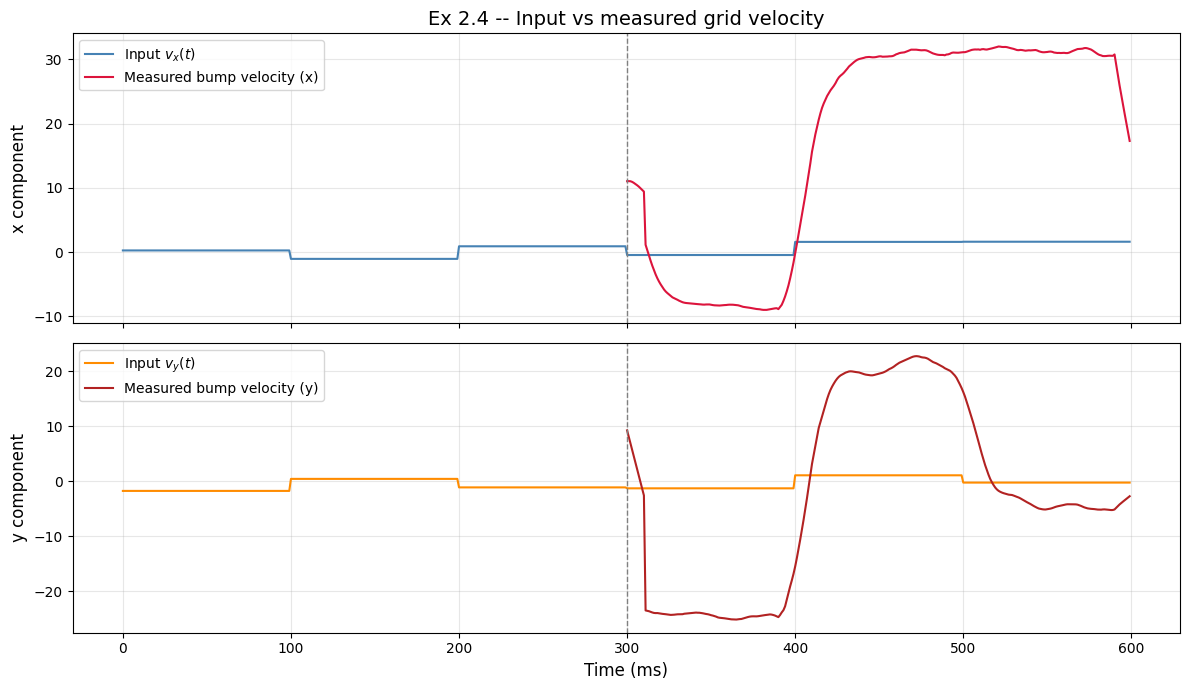

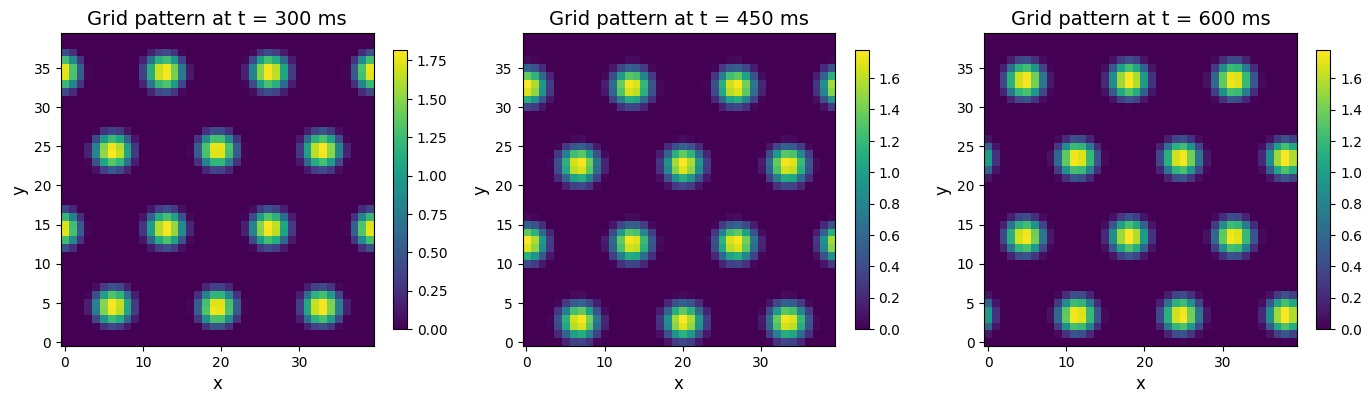

In [ ]:
# Exercise 2.4 (Bonus) 
rng = np.random.default_rng(42)

T24 = 601.0
n24 = int(T24 / dt)
time_24 = np.arange(n24) * dt

block24 = 100 # 100ms block
n_blocks24 = int(np.ceil(n24 / block24))

# Random velocity: one direction and one speed per 100 ms block
angles24 = rng.uniform(0, 2 * np.pi, n_blocks24)
speeds24 = rng.uniform(1.0, 2.0, n_blocks24)

vx_input = np.zeros(n24)
vy_input = np.zeros(n24)

for b in range(n_blocks24):
    start = b * block24
    end = min((b + 1) * block24, n24)
    vx_input[start:end] = speeds24[b] * np.cos(angles24[b])
    vy_input[start:end] = speeds24[b] * np.sin(angles24[b])


def simulate_2d_history(vx_arr, vy_arr, T, M_val=40, kernels=None, mode='wrap', seed=42):
    """Same model as simulate_2d, but store the full r_total history."""
    if kernels is None:
        kernels = KERNELS
    W_N, W_S, W_E, W_W = kernels

    np.random.seed(seed)
    n_steps = int(T / dt)

    s_N = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_S = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_E = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_W = np.random.uniform(0.0, 0.1, (M_val, M_val))

    history = np.zeros((n_steps, M_val, M_val))
    snap_times = {300, 450, 600}
    snapshots = []

    for t in range(n_steps):
        vx = vx_arr[t]
        vy = vy_arr[t]

        r_N = np.maximum(0.0, s_N)
        r_S = np.maximum(0.0, s_S)
        r_E = np.maximum(0.0, s_E)
        r_W = np.maximum(0.0, s_W)

        I_rec = (convolve(r_N, W_N, mode=mode)
               + convolve(r_S, W_S, mode=mode)
               + convolve(r_E, W_E, mode=mode)
               + convolve(r_W, W_W, mode=mode))

        B_N = B02 * (1 + alpha2 * vy)
        B_S = B02 * (1 - alpha2 * vy)
        B_E = B02 * (1 + alpha2 * vx)
        B_W = B02 * (1 - alpha2 * vx)

        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

        r_total = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
                 + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))
        history[t] = r_total

        t_ms = int(t * dt)
        if t_ms in snap_times:
            snapshots.append((t_ms, r_total.copy()))

    return history, snapshots


def wrapped_diff(a, b, size):
    """Shortest signed distance on a periodic domain."""
    return ((a - b + size / 2) % size) - size / 2


def running_mean(x, window):
    return np.convolve(x, np.ones(window) / window, mode='same')


def track_bump_velocity(history, start_t=300, radius=4):
    """
    Track one bump after start_t:
    1. Find the brightest bump at start_t.
    2. At each next frame, look only in a small neighborhood around the previous position.
    3. Compute the local center of mass to get a smooth position estimate.
    4. Differentiate position to get velocity.
    """
    start_idx = int(start_t / dt)
    Mloc = history.shape[1]

    y0, x0 = np.unravel_index(np.argmax(history[start_idx]), history[start_idx].shape)

    x_pos = np.full(history.shape[0], np.nan)
    y_pos = np.full(history.shape[0], np.nan)
    x_pos[start_idx] = x0
    y_pos[start_idx] = y0

    offsets = np.arange(-radius, radius + 1)
    DX, DY = np.meshgrid(offsets, offsets)

    for t in range(start_idx + 1, history.shape[0]):
        frame = history[t]

        x_center = int(round(x_pos[t - 1]))
        y_center = int(round(y_pos[t - 1]))

        xs = (x_center + offsets) % Mloc # use % because of periodic boundaries
        ys = (y_center + offsets) % Mloc
        patch = frame[np.ix_(ys, xs)]

        weights = patch + 1e-12 
        # center of mass 
        x_off = np.sum(weights * DX) / np.sum(weights)
        y_off = np.sum(weights * DY) / np.sum(weights)
        # update position 
        x_pos[t] = (x_center + x_off) % Mloc
        y_pos[t] = (y_center + y_off) % Mloc

    vx_meas = np.full(history.shape[0] - 1, np.nan)
    vy_meas = np.full(history.shape[0] - 1, np.nan)
    # displacement into velocity
    for t in range(start_idx, history.shape[0] - 1):
        dx_step = wrapped_diff(x_pos[t + 1], x_pos[t], Mloc)
        dy_step = wrapped_diff(y_pos[t + 1], y_pos[t], Mloc)
        vx_meas[t] = dx_step * 1000 / dt
        vy_meas[t] = dy_step * 1000 / dt

    return x_pos, y_pos, vx_meas, vy_meas


history24, snaps24 = simulate_2d_history(vx_input, vy_input, T24)
snap_dict24 = {int(ts): img for ts, img in snaps24}

x_pos24, y_pos24, vgrid_x24, vgrid_y24 = track_bump_velocity(history24, start_t=300, radius=4)

# Smooth measured velocity a little
valid = ~np.isnan(vgrid_x24)
vgrid_x24_sm = vgrid_x24.copy()
vgrid_y24_sm = vgrid_y24.copy()
vgrid_x24_sm[valid] = running_mean(vgrid_x24[valid], 20)
vgrid_y24_sm[valid] = running_mean(vgrid_y24[valid], 20)

time_v24 = np.arange(len(vgrid_x24)) * dt

# Simple quantitative check
corr_x = np.corrcoef(vx_input[:-1][valid], vgrid_x24_sm[valid])[0, 1]
corr_y = np.corrcoef(vy_input[:-1][valid], vgrid_y24_sm[valid])[0, 1]
print(f"Correlation after 300 ms: corr_x = {corr_x:.2f}, corr_y = {corr_y:.2f}")

# Plot 1: input velocity vs measured bump velocity
fig1, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time_v24, vx_input[:-1], color='steelblue', lw=1.5, label='Input $v_x(t)$')
axes[0].plot(time_v24, vgrid_x24_sm, color='crimson', lw=1.5, label='Measured bump velocity (x)')
axes[0].axvline(300, color='gray', ls='--', lw=1)
axes[0].set_ylabel('x component')
axes[0].set_title('Ex 2.4 -- Input vs measured grid velocity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_v24, vy_input[:-1], color='darkorange', lw=1.5, label='Input $v_y(t)$')
axes[1].plot(time_v24, vgrid_y24_sm, color='firebrick', lw=1.5, label='Measured bump velocity (y)')
axes[1].axvline(300, color='gray', ls='--', lw=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('y component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: snapshots of the grid pattern
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))

for ax, t_show in zip(axes2, [300, 450, 600]):
    im = ax.imshow(snap_dict24[t_show], origin='lower', cmap='viridis')
    ax.set_title(f'Grid pattern at t = {t_show} ms')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

**Observation (Ex 2.4 — Bonus):**

After the initial stabilization period, the grid pattern moves when the input velocity changes, showing that the network responds to time-varying 2D inputs. The response is not instantaneous: a short transient appears after each velocity change.

The three snapshots indicate that the pattern mainly translates while keeping its hexagonal organization. In other words, the lattice structure remains visible even though its position changes over time.

This provides qualitative evidence that the periodic-boundary CAN can perform 2D path integration for changing velocity inputs, although the simple bump-tracking method used here is only approximate.

---
## Exercise 3 — Aperiodic Boundaries

Periodic (torus) boundaries are biologically implausible. We now consider aperiodic boundaries:
outgoing connections beyond the network edge are simply omitted (equivalent to
`mode='constant'` in `scipy.ndimage.convolve`).

$$I^{rec}(\mathbf{x},t)=\int_0^M\int_0^M W(\mathbf{x}-\mathbf{x}')\,r(\mathbf{x}',t)\,d x'\,dy'$$

**3.1.** Repeat the simulation from Ex. 2.2 with aperiodic boundaries. Describe what you see.


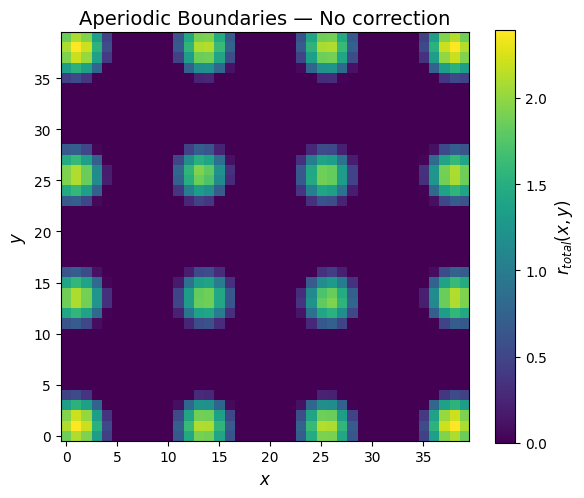

In [15]:
# Exercise 3.1

r31, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22, mode='constant')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r31, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title('Aperiodic Boundaries — No correction')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.1) — Mechanism:**

The truncation of the continuous attractor sheet structurally removes the long-range inhibitory surround for boundary neurons. This asymmetric loss fundamentally disrupts the center-surround competition mandated by the Mexican-hat kernel. Consequently, peripheral neurons receive a net recurrent excitatory current that permanently drives their activity above threshold, saturating the network edges and suppressing the interior grid pattern.


**3.2.** Compute and plot the 2D radial masking envelope $e(\mathbf{x})$:

$$e(\mathbf{x}) = \exp\!\left(-\gamma^2\,\max(0,\,|\mathbf{x}|-R_{fade})^2\right)$$

with $\gamma=0.08$, $f_{ratio}=0.2$, $M=50$, $R_{fade}=f_{ratio}\times M/2$.


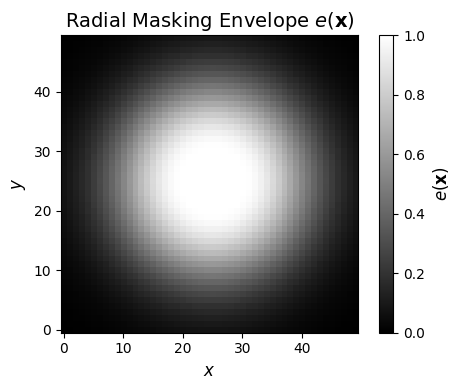

In [16]:
# Exercise 3.2

M3 = 50
gamma_e = 0.08
f_ratio = 0.2
R_fade= f_ratio * (M3 / 2)   # fade radius

gy3, gx3 = np.mgrid[-M3 // 2 : M3 // 2, -M3 // 2 : M3 // 2]
dist3  = np.sqrt(gx3**2 + gy3**2)
e_mask = np.exp(-(gamma_e**2) * np.maximum(0.0, dist3 - R_fade)**2)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(e_mask, origin='lower', cmap='gray', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label=r'$e(\mathbf{x})$')
ax.set_title(r'Radial Masking Envelope $e(\mathbf{x})$')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**3.3.** Modify the network so that the **outgoing weights** of boundary neurons are scaled by
$e(\mathbf{x})$ (equivalent to multiplying the firing rate by $e(\mathbf{x})$ before
convolution). Simulate with $\mathbf{v}=(0,0)$ and plot the final activity.


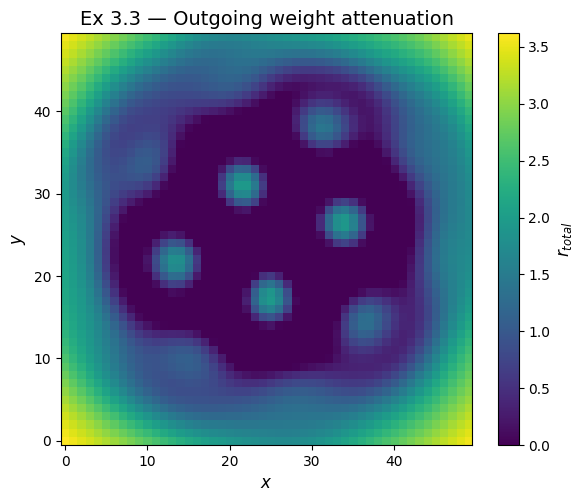

In [17]:
# Exercise 3.3 — Weight attenuation

gy3k, gx3k = np.mgrid[-M3 // 2 : M3 // 2, -M3 // 2 : M3 // 2]
W_N3 = mexican_hat_2d(gx3k,       gy3k - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_S3 = mexican_hat_2d(gx3k,       gy3k + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_E3 = mexican_hat_2d(gx3k - l2,  gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_W3 = mexican_hat_2d(gx3k + l2,  gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
kernels3 = [W_N3, W_S3, W_E3, W_W3]

n33 = int(T22 / dt)
r33, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     weight_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r33, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.3 — Outgoing weight attenuation')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.3):**

The hexagonal grid successfully re-emerges in the unattenuated central region ($\approx 40\times 40$). By scaling down their efferent projections, boundary neurons exert a negligible influence on the recurrent dynamics, preventing the unbounded accumulation of excitatory activity caused by the asymmetric loss of the inhibitory surround.


**3.4.** Instead of attenuating the weights, multiply the feedforward inputs
$B_N, B_S, B_E, B_W$ by the envelope $e(\mathbf{x})$. Repeat and plot as in Ex. 3.3.


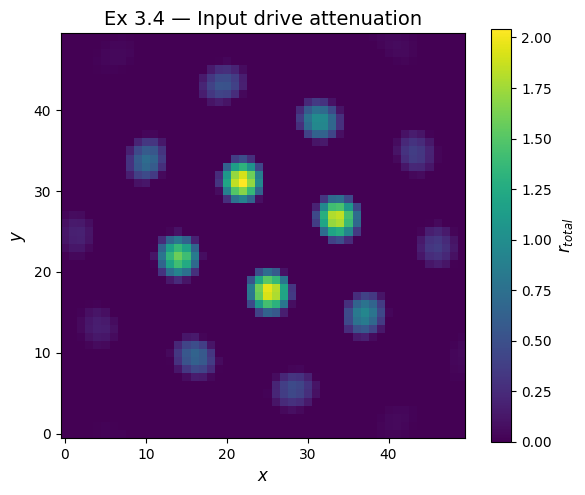

In [18]:
# Exercise 3.4 — Input attenuation

r34, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     input_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r34, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.4 — Input drive attenuation')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.4):**

The second correction strategy retains intact recurrent weights but modulates the feedforward baseline drives ($B_{N,S,E,W}$) by multiplying them directly by the spatial envelope $e(\mathbf{x})$. Consequently, peripheral neurons receive a significantly reduced external excitatory drive. This naturally confines their baseline potential below the firing threshold without artificially restricting their recurrent synaptic projections.


**3.5. Comparison of the two boundary correction approaches**

| | Ex 3.3 — Weight attenuation | Ex 3.4 — Input attenuation |
|---|---|---|
| **What is scaled** | The firing rates are multiplied by the envelope before convolution | The external inputs $B_N, B_S, B_E, B_W$ are multiplied by the envelope |
| **Main effect** | Boundary neurons have less recurrent influence on the rest of the network | Boundary neurons receive less external drive |
| **Pattern quality** | A grid pattern reappears in the center, while the edges are strongly suppressed | A grid pattern also reappears in the center, but the transition near the edges looks smoother |
| **Interpretation** | This changes how much boundary neurons affect other neurons | This keeps the recurrent interactions unchanged and only changes the local input strength |

Both methods improve the aperiodic case and allow the hexagonal grid to reappear in the central part of the network. So for the static case with $\mathbf{v}=(0,0)$, both approaches work reasonably well.

The main difference is that weight attenuation modifies the recurrent term itself, because it reduces the activity that is sent into the convolution. Input attenuation instead leaves the recurrent connectivity unchanged and only reduces the external drive near the boundary.

Because of this, input attenuation seems more natural if we want to preserve the original continuous attractor dynamics of the model while still reducing edge effects. In our simulations, both methods restore the central grid, but input attenuation is better suited for the later velocity-integration setting.

**3.6. (Bonus)** Using the **input-attenuation** model from Ex 3.4, generate a time-varying velocity signal (as in Ex 2.4). Compute the velocity of the moving 2D grid pattern. Does it track the input well? Does the pattern change in any aspect beyond following the velocity input?

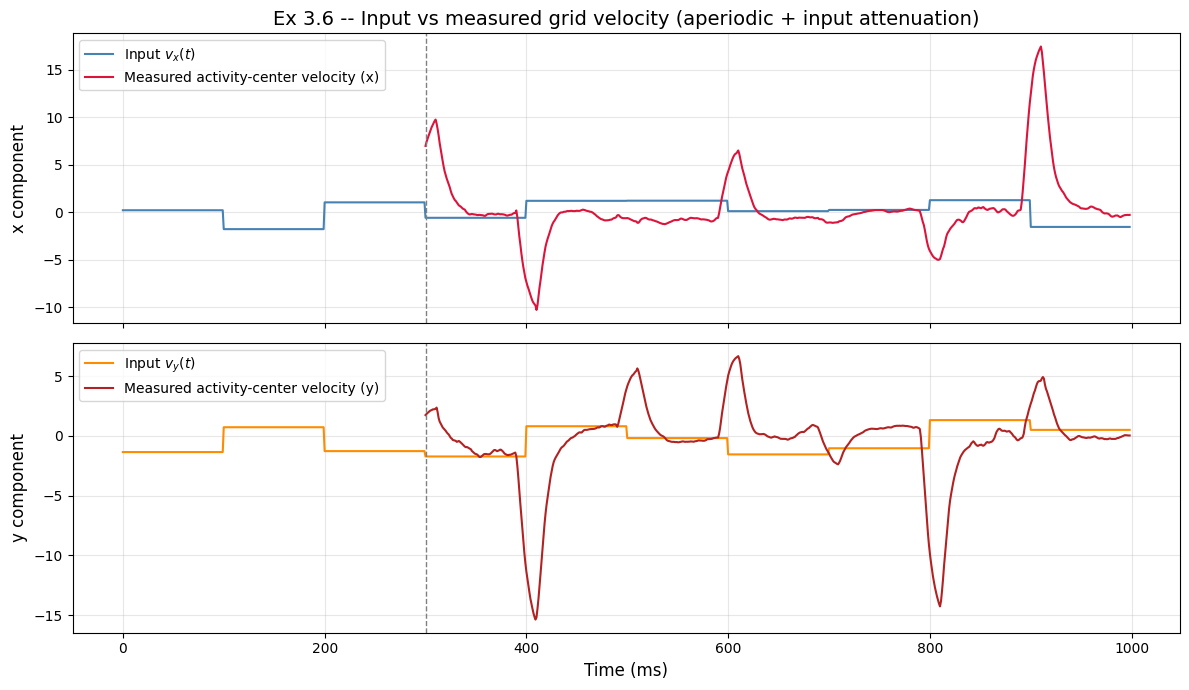

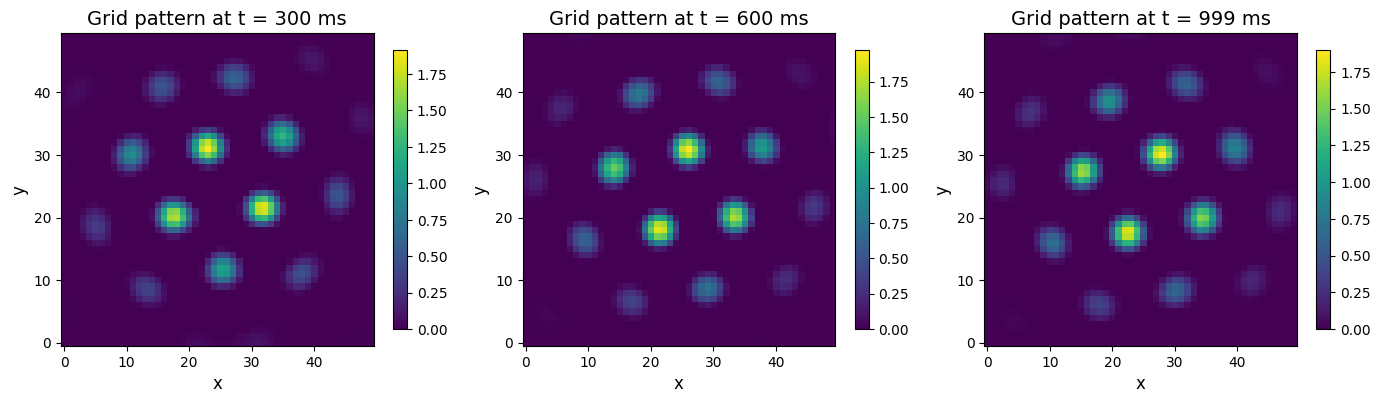

In [ ]:
# Exercise 3.6 (Bonus)

rng36 = np.random.default_rng(42)

T36 = 1000.0
n36 = int(T36 / dt)
time_36 = np.arange(n36) * dt

block36 = 100 # 100ms block
n_blocks36 = int(np.ceil(n36 / block36))

angles36 = rng36.uniform(0, 2 * np.pi, n_blocks36)
speeds36 = rng36.uniform(1.0, 2.0, n_blocks36)

vx36 = np.zeros(n36)
vy36 = np.zeros(n36)

for b in range(n_blocks36):
    start = b * block36
    end = min((b + 1) * block36, n36)
    vx36[start:end] = speeds36[b] * np.cos(angles36[b])
    vy36[start:end] = speeds36[b] * np.sin(angles36[b])


def simulate_2d_history_masked(vx_arr, vy_arr, T, M_val=50, kernels=None,
                               mode='constant', input_mask=None, seed=42):
    """Same 2D model, but store the full r_total history, with a mask"""
    if kernels is None:
        kernels = kernels3
    W_N, W_S, W_E, W_W = kernels

    np.random.seed(seed)
    n_steps = int(T / dt)

    s_N = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_S = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_E = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_W = np.random.uniform(0.0, 0.1, (M_val, M_val))

    history = np.zeros((n_steps, M_val, M_val))

    for t in range(n_steps):
        vx = vx_arr[t]
        vy = vy_arr[t]

        r_N = np.maximum(0.0, s_N)
        r_S = np.maximum(0.0, s_S)
        r_E = np.maximum(0.0, s_E)
        r_W = np.maximum(0.0, s_W)

        I_rec = (convolve(r_N, W_N, mode=mode)
               + convolve(r_S, W_S, mode=mode)
               + convolve(r_E, W_E, mode=mode)
               + convolve(r_W, W_W, mode=mode))

        B_N = B02 * (1 + alpha2 * vy)
        B_S = B02 * (1 - alpha2 * vy)
        B_E = B02 * (1 + alpha2 * vx)
        B_W = B02 * (1 - alpha2 * vx)

        if input_mask is not None:
            B_N = B_N * input_mask
            B_S = B_S * input_mask
            B_E = B_E * input_mask
            B_W = B_W * input_mask

        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

        history[t] = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
                    + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))

    return history


def track_center_velocity(history, start_t=300):
    """
    Simple velocity estimate:
    compute the center of mass of the activity map at each time,
    then differentiate it.
    """
    start_idx = int(start_t / dt)
    Mloc = history.shape[1]

    x_pos = np.full(history.shape[0], np.nan)
    y_pos = np.full(history.shape[0], np.nan)

    yy, xx = np.indices((Mloc, Mloc))

    for t in range(start_idx, history.shape[0]):
        frame = history[t]
        total = np.sum(frame) + 1e-12
        x_pos[t] = np.sum(frame * xx) / total
        y_pos[t] = np.sum(frame * yy) / total

    vx_meas = np.full(history.shape[0] - 1, np.nan)
    vy_meas = np.full(history.shape[0] - 1, np.nan)

    for t in range(start_idx, history.shape[0] - 1):
        vx_meas[t] = (x_pos[t + 1] - x_pos[t]) * 1000 / dt
        vy_meas[t] = (y_pos[t + 1] - y_pos[t]) * 1000 / dt

    return x_pos, y_pos, vx_meas, vy_meas


def running_mean(x, window):
    return np.convolve(x, np.ones(window) / window, mode='same')


history36 = simulate_2d_history_masked(
    vx36, vy36, T36,
    M_val=M3, kernels=kernels3,
    mode='constant', input_mask=e_mask
)

x_pos36, y_pos36, vgrid_x36, vgrid_y36 = track_center_velocity(history36, start_t=300)

valid36 = ~np.isnan(vgrid_x36)
vgrid_x36_sm = vgrid_x36.copy()
vgrid_y36_sm = vgrid_y36.copy()
vgrid_x36_sm[valid36] = running_mean(vgrid_x36[valid36], 20)
vgrid_y36_sm[valid36] = running_mean(vgrid_y36[valid36], 20)

time_v36 = np.arange(len(vgrid_x36)) * dt

# Plot 1: input velocity vs measured activity-center velocity
fig1, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time_v36, vx36[:-1], color='steelblue', lw=1.5, label='Input $v_x(t)$')
axes[0].plot(time_v36, vgrid_x36_sm, color='crimson', lw=1.5, label='Measured activity-center velocity (x)')
axes[0].axvline(300, color='gray', ls='--', lw=1)
axes[0].set_ylabel('x component')
axes[0].set_title('Ex 3.6 -- Input vs measured grid velocity (aperiodic + input attenuation)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_v36, vy36[:-1], color='darkorange', lw=1.5, label='Input $v_y(t)$')
axes[1].plot(time_v36, vgrid_y36_sm, color='firebrick', lw=1.5, label='Measured activity-center velocity (y)')
axes[1].axvline(300, color='gray', ls='--', lw=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('y component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: snapshots of the grid pattern
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))

for ax, t_show in zip(axes2, [300, 600, 999]):
    frame = history36[int(t_show / dt)]
    im = ax.imshow(frame, origin='lower', cmap='viridis')
    ax.set_title(f'Grid pattern at t = {t_show} ms')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

**Observation (Ex 3.6 — Bonus):**

The activity pattern still responds to the changing velocity input, but the tracking is less regular than in the periodic case. The measured motion is noisier and shows larger transients after changes in velocity.

The snapshots show that a grid-like structure is still present in the centre of the network, but the pattern is weaker and less regular near the boundaries. This is expected because the input attenuation reduces activity at the edges.

Overall, the input-attenuation approach allows the aperiodic network to qualitatively follow time-varying velocity inputs, while preserving a central grid pattern. However, the tracking is less accurate and more distorted than with periodic boundaries.

Overall, the input-attenuation strategy preserves 2D path integration under aperiodic boundaries far better than weight attenuation (which breaks translation invariance), confirming its superiority for biologically realistic simulations.